In [1]:
import sys  
sys.path.insert(1, '~/autodriving/self-training-segmentation')

from dataset.ugm import UGMDataset
from utils import colorize_segmentation

/home/esr/miniconda3/envs/autodriving/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ugm_dataset = UGMDataset(
    '/media/esr/ssd0/dataset/2025-01-10/', 
    size=(256, 256), 
    return_teacher_logits=True, 
    use_refinement=True, 
    entropy_threshold=1.0,
    use_transform=False,
)

for i in range(len(ugm_dataset)):
    image, t_logits, refined_label = ugm_dataset[i]
    print(f"Image shape: {image.shape}, Teacher logits shape: {t_logits.shape if t_logits is not None else 'N/A'}, Refined label shape: {refined_label.shape if refined_label is not None else 'N/A'}")
    break

Image shape: torch.Size([3, 256, 256]), Teacher logits shape: torch.Size([19, 256, 256]), Refined label shape: torch.Size([256, 256])


/tmp/ipykernel_1607332/4197123904.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  colorized_refined_label = colorize_segmentation(torch.tensor(refined_label)).numpy()


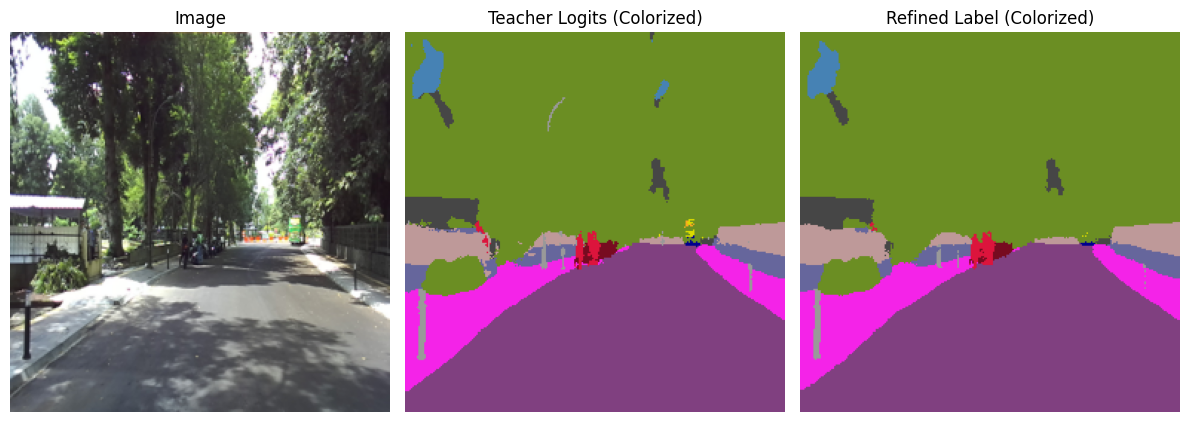

In [3]:
import torch
import matplotlib.pyplot as plt

image, t_logits, refined_label = ugm_dataset[20]

image = image.numpy().transpose(1, 2, 0)
t_label = t_logits.argmax(dim=0).numpy()
colorized_label = colorize_segmentation(torch.tensor(t_label)).numpy()
colorized_refined_label = colorize_segmentation(torch.tensor(refined_label)).numpy()

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Image")
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(colorized_label.transpose(1, 2, 0))
plt.title("Teacher Logits (Colorized)")
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(colorized_refined_label.transpose(1, 2, 0))
plt.title("Refined Label (Colorized)")
plt.axis('off')
plt.tight_layout()
plt.show()